# Procurement Delivery Risk

**Atul Iwale · AEC Intelligence Portfolio · executed synthetic-data walkthrough**

> **Decision:** Which newly issued orders should receive early buyer follow-up?

[Case study](https://github.com/AtulIwale/Portfolio/tree/main/projects/05-delivery-risk) ·
[Data assumptions](https://github.com/AtulIwale/Portfolio/blob/main/docs/DATA_CARD.md) ·
[Portfolio](https://github.com/AtulIwale/Portfolio)

Read the narrative, tables and saved charts on GitHub; no installation is required to read.
To reproduce, use **Runtime → Run all** in a fresh Colab session. The first cell downloads
the public repository and installs dependencies only in Colab. Locally, install
`requirements-notebooks.txt` and open this notebook from the repository.

All data is fictional. Results demonstrate an analytical approach, not proven client impact.

## 1. Reproducible setup

The notebook verifies the dataset hashes and imports reusable project functions. The
important decisions and calculations remain visible below. Saved outputs were produced
by executing all cells in a fresh Python process with IPython rich output capture.
Local Jupyter kernel sockets were unavailable; the hosted Colab service was not used for validation.

In [1]:
from pathlib import Path
import os, sys, subprocess, tempfile

# Pin the computational source/data so later edits to main do not change this walkthrough.
SOURCE_REV = "363f7edcd6c2357bc167257fce4e36b771b216d6"
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "aec/features.py").exists()), None)
if ROOT is None:
    ROOT = Path(tempfile.mkdtemp(prefix="aec-portfolio-")) / "Portfolio"
    subprocess.run(["git", "clone", "--quiet", "https://github.com/AtulIwale/Portfolio.git", str(ROOT)], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "--quiet", SOURCE_REV], check=True)
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(ROOT / "requirements.txt"), "matplotlib==3.10.8"], check=True)
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
os.environ.setdefault("OMP_NUM_THREADS", "2")
print("Source:", SOURCE_REV if IN_COLAB else "local checkout")
print("Data: synthetic only; no client information or credentials required.")

Source: local checkout
Data: synthetic only; no client information or credentials required.


In [2]:
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aec.data import load_dataset

tables = load_dataset(ROOT / "data")
manifest = json.loads((ROOT / "data/manifest.json").read_text())
for name, spec in manifest["tables"].items():
    assert hashlib.sha256((ROOT / f"data/{name}.jsonl").read_bytes()).hexdigest() == spec["sha256"], name
plt.rcParams.update({"figure.figsize": (10, 4.8), "figure.dpi": 120,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": "#2D4653", "text.color": "#2D4653", "axes.titleweight": "bold",
    "axes.prop_cycle": plt.cycler(color=["#3F7285", "#B6A78E", "#2D4653", "#899BA5"])})
FIGURES = ROOT / "outputs/notebook-figures"
FIGURES.mkdir(parents=True, exist_ok=True)
def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=140, bbox_inches="tight", facecolor="white")
    plt.show()
print(f"Verified {len(tables)} tables / {sum(len(t) for t in tables.values()):,} synthetic rows against manifest hashes.")

Verified 12 tables / 28,682 synthetic rows against manifest hashes.


## 2. Define the prediction moment and label

The model scores an order **when it is issued**. A late outcome means full gross receipt
after required-by date. Rejected quantities are separate; delivery completion does not mean
quality acceptance. Open/partial orders have unknown outcomes and must not become negatives.

I start with censoring and label frequency because a model can look successful by ignoring
difficult open orders. Required-by dates may also reflect negotiation or unrealistic planning.

In [3]:
from aec.features import delivery_features, split_mature, DELIVERY_NUM, DELIVERY_CAT
from aec.models import pipeline, classification_metrics, evaluate_delivery
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score

f=delivery_features(tables)
display(pd.Series({"all_orders":len(f),"labelled_completed":int(f.complete.sum()),
    "unlabelled_open":int((~f.complete).sum()),"late_fraction_completed":f.late.mean()}).to_frame("Value"))
display(f[["order_id","order_date","required_by","completion_date","late","supplier_prior_completed"]].head())

,Value
all_orders,3600.00
labelled_completed,3500.00
unlabelled_open,100.00
late_fraction_completed,0.39


,order_id,order_date,required_by,completion_date,late,supplier_prior_completed
0,O000000,2022-01-01,2022-01-17,2022-01-20,1.0,0
1,O000001,2022-01-01,2022-02-12,2022-02-07,0.0,0
2,O000002,2022-01-02,2022-02-25,2022-03-03,1.0,0
3,O000003,2022-01-02,2022-01-21,2022-01-27,1.0,0
4,O000004,2022-01-02,2022-02-18,2022-02-25,1.0,0


## 3. Features: learn from information already available

Quantity, value, lead days, month and material category are known at issue time. Supplier
history uses only orders completed **before** this order's date, smoothed with a Beta(1,1)
prior. No current-order receipt, payment or final-delay field is a predictor. Numeric imputation,
scaling and category encoding are fitted inside the training pipeline.

Historical features update as earlier orders finish, including during the test period; the
model itself stays frozen. This represents sequential scoring, not one bulk forecast at test start.

In [4]:
cols=DELIVERY_NUM+DELIVERY_CAT
assert not {"late","completion_date","received_qty"}.intersection(cols)
sample=f.iloc[700]
history=f[(f.supplier_id==sample.supplier_id)&(f.completion_date<sample.order_date)&f.complete]
assert len(history)==sample.supplier_prior_completed
display(pd.DataFrame({"feature":cols,"available_at_issue":[True]*len(cols)}))
print("One audited history count:",len(history),"completed prior orders")

One audited history count: 10 completed prior orders


,feature,available_at_issue
0,quantity,True
1,amount,True
2,lead_days,True
3,order_month,True
4,supplier_prior_late_rate,True
5,supplier_prior_completed,True
6,category,True


## 4. Split by time and by when the label becomes known

Training requires issue and completion before January 2023. Validation requires issue from
January 2023 and completion before July 2024. Later orders form the held-out test set.
Boundary-spanning outcomes are purged. Random splitting would hide the later regime shift.

,split,rows,issue_start,issue_end,late_rate
0,Train,814,2022-01-01,2022-12-27,0.356265
1,Validation,1260,2023-01-01,2024-06-23,0.334127
2,Test,1243,2024-07-01,2025-12-21,0.461786


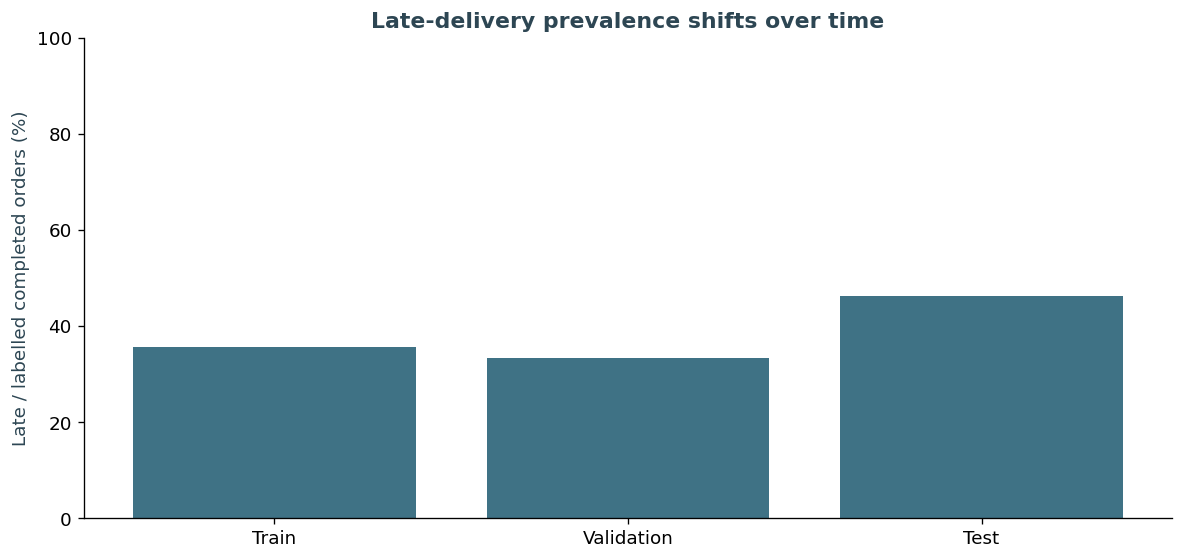

In [5]:
train,val,test=split_mature(f,"order_date","late")
parts={"Train":train,"Validation":val,"Test":test}
display(pd.DataFrame([{"split":name,"rows":len(part),"issue_start":part.order_date.min(),
    "issue_end":part.order_date.max(),"late_rate":part.late.mean()} for name,part in parts.items()]))
fig,ax=plt.subplots()
ax.bar(list(parts),[p.late.mean()*100 for p in parts.values()])
ax.set(title="Late-delivery prevalence shifts over time",ylabel="Late / labelled completed orders (%)",ylim=(0,100))
finish(fig,"05-label-shift")

## 5. Compare a simple baseline before increasing complexity

I compare a constant-prior baseline, logistic regression and two shallow boosting settings.
Validation **average precision** selects the candidate because prioritising late orders is the
task. This is a small candidate comparison, not an exhaustive tuning exercise. Test results
must not change the selected model.

In [6]:
candidates={"dummy":DummyClassifier(strategy="prior"),"logistic":LogisticRegression(max_iter=1000)}
for leaves in [7,15]:
    candidates[f"boosting_{leaves}"]=HistGradientBoostingClassifier(max_leaf_nodes=leaves,max_iter=100,
        l2_regularization=2,early_stopping=False,random_state=42)
fitted={}; comparison=[]
for name,estimator in candidates.items():
    fitted[name]=pipeline(estimator,DELIVERY_NUM,DELIVERY_CAT).fit(train[cols],train.late)
    probability=fitted[name].predict_proba(val[cols])[:,1]
    comparison.append({"model":name,"validation_AP":average_precision_score(val.late,probability)})
comparison=pd.DataFrame(comparison).sort_values("validation_AP",ascending=False)
selected=comparison.iloc[0].model
display(comparison)
print("Selected on validation only:",selected)

Selected on validation only: logistic


,model,validation_AP
1,logistic,0.481734
2,boosting_7,0.457319
3,boosting_15,0.450486
0,dummy,0.334127


## 6. Translate scores into a review threshold

The demonstration assigns cost 5 to a missed late order and cost 1 to unnecessary follow-up.
These are scenario loss units, not measured money. The validation set selects the threshold;
the same threshold is then frozen for test evaluation. Review capacity could justify a different
policy and must be agreed with buyers.

Frozen threshold: 0.15; test review workload: 83.0%


,selected,dummy
roc_auc,0.642131,0.500000
average_precision,0.602363,0.461786
brier,0.288013,0.259674
precision,0.494186,0.461786
recall,0.888502,1.000000
f1,0.635118,0.631811
threshold,0.150000,0.150000
n,1243.000000,1243.000000


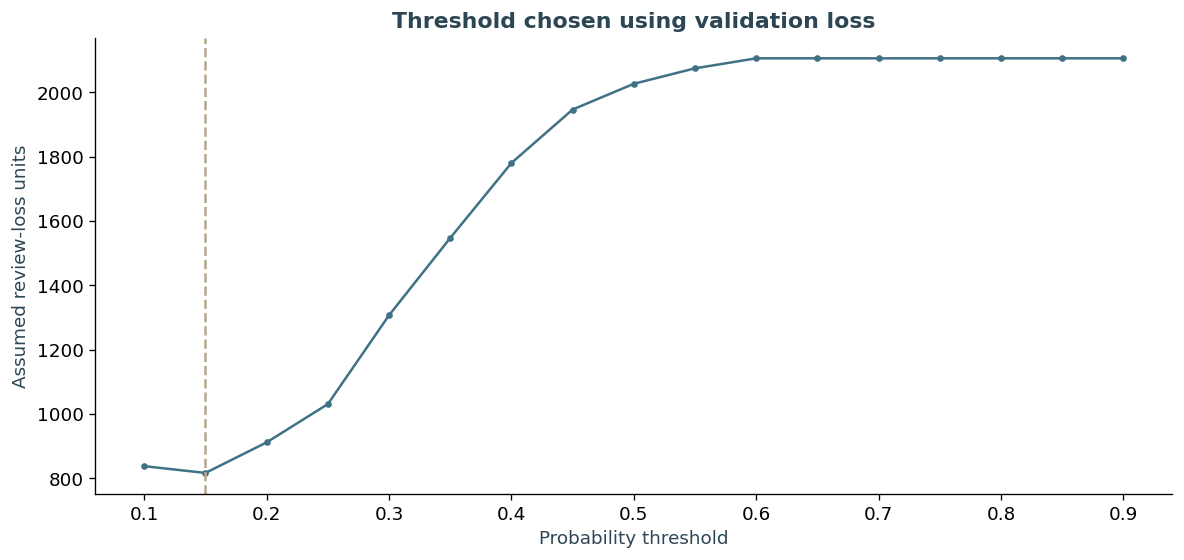

In [7]:
vp=fitted[selected].predict_proba(val[cols])[:,1]
thresholds=np.arange(.1,.91,.05)
losses=[5*np.sum((vp<t)&(val.late==1))+np.sum((vp>=t)&(val.late==0)) for t in thresholds]
threshold=float(thresholds[np.argmin(losses)])
p=fitted[selected].predict_proba(test[cols])[:,1]
display(pd.DataFrame({"selected":classification_metrics(test.late,p,threshold),
    "dummy":classification_metrics(test.late,fitted["dummy"].predict_proba(test[cols])[:,1],threshold)}))
print(f"Frozen threshold: {threshold:.2f}; test review workload: {np.mean(p>=threshold):.1%}")
fig,ax=plt.subplots()
ax.plot(thresholds,losses,marker="."); ax.axvline(threshold,linestyle="--",color="#B6A78E")
ax.set(title="Threshold chosen using validation loss",xlabel="Probability threshold",ylabel="Assumed review-loss units")
finish(fig,"05-threshold")

## 7. Check calibration, explanations and weak spots

The shared audit function recomputes the same locked experiment and adds category slices,
calibration bins, a fixed-model bootstrap and permutation importance. A high ranking score
does not imply accurate probabilities. Permutation importance is global association, not a
causal explanation for an individual supplier.

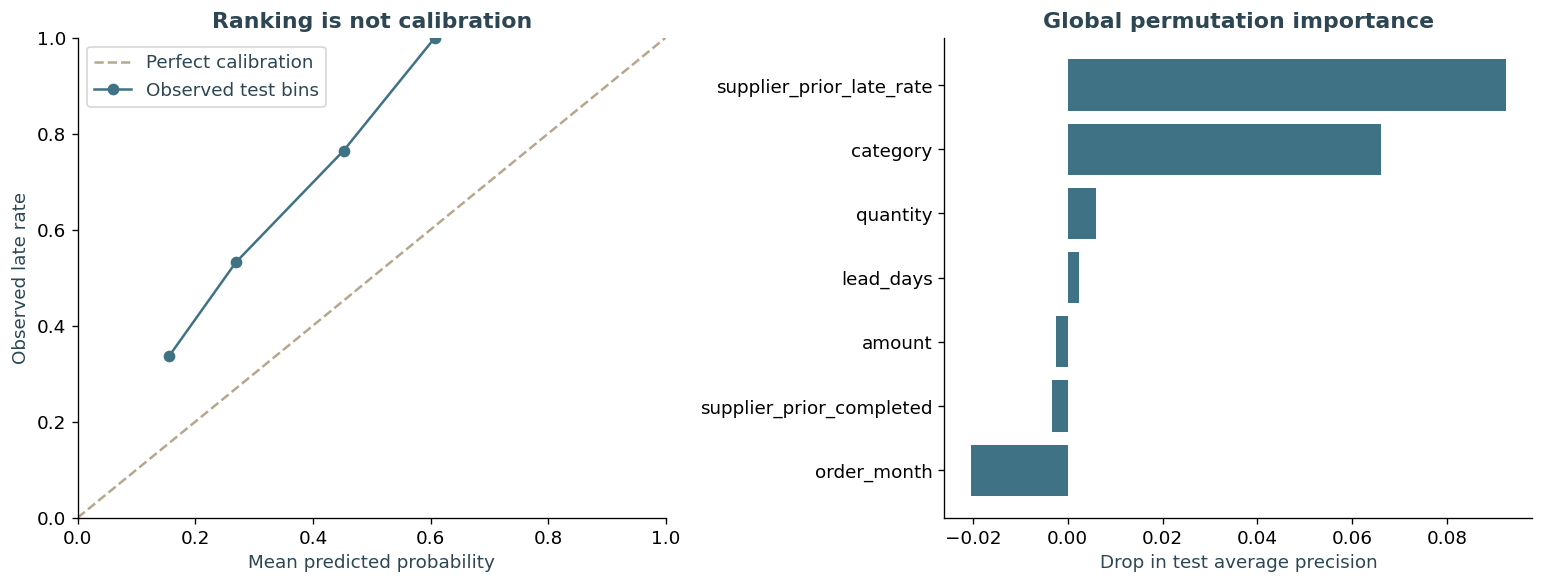

,n,average_precision,precision,recall
Concrete,221.0,0.514453,0.477011,0.902174
Earthworks,268.0,0.502975,0.429787,0.918182
Finishes,272.0,0.460566,0.411429,0.666667
MEP,240.0,0.735664,0.633333,1.000000
Steel,242.0,0.603261,0.490385,0.910714


,order_id,supplier_id,project_id,amount,late,late_probability,review
2357,O002357,S031,P016,222271.80,1.0,0.607547,True
2525,O002525,S014,P029,88850.72,1.0,0.583080,True
3363,O003363,S031,P016,78782.40,1.0,0.565765,True
2531,O002531,S014,P008,61023.95,1.0,0.542282,True
2671,O002671,S011,P007,41304.09,1.0,0.529776,True
3183,O003183,S031,P022,324468.10,1.0,0.523235,True
2619,O002619,S052,P005,176181.48,0.0,0.522051,True
3026,O003026,S031,P001,75562.25,1.0,0.509943,True


**Brier (lower is better):** model 0.288; dummy 0.260. **AP bootstrap 95%:** 0.558–0.639.

In [8]:
report,queue=evaluate_delivery(f)
assert report["selected_model"]==selected
assert np.isclose(report["test"]["average_precision"],average_precision_score(test.late,p))
bins=pd.DataFrame(report["calibration_bins"])
importance=pd.Series(report["permutation_importance"]).sort_values()
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].plot([0,1],[0,1],linestyle="--",color="#B6A78E",label="Perfect calibration")
axes[0].plot(bins.predicted,bins.observed,marker="o",label="Observed test bins")
axes[0].set(xlabel="Mean predicted probability",ylabel="Observed late rate",title="Ranking is not calibration",xlim=(0,1),ylim=(0,1));axes[0].legend()
axes[1].barh(importance.index,importance.values);axes[1].set(title="Global permutation importance",xlabel="Drop in test average precision")
finish(fig,"05-calibration-importance")
display(pd.DataFrame(report["slices"]).T[["n","average_precision","precision","recall"]])
display(queue.head(8))
display(Markdown(f"**Brier (lower is better):** model {report['test']['brier']:.3f}; dummy {report['baseline_test']['brier']:.3f}. **AP bootstrap 95%:** {report['test_ap_bootstrap_95'][0]:.3f}–{report['test_ap_bootstrap_95'][1]:.3f}."))

## 8. What I would recommend

In the committed seed-42 run, logistic regression wins validation selection. Test ranking
improves on the dummy, but Brier probability error is worse under the simulated shift. I would
not deploy these probabilities. The high-recall threshold also creates substantial buyer work.

Next: validate labels, compare to operational rules, assess capacity, reserve new calibration
data and run shadow review on authorised real observations. Test-period findings are diagnostic;
they are not used here to tune a better-looking answer on the same holdout.

**Limits:** synthetic signal recovery, completed-order selection bias, few candidate models,
correlated supplier observations and bootstrap intervals conditional on one fitted model.
No prevented delays or cost savings are claimed.

**Interview discussion:** Why can ranking improve while probability accuracy worsens? What
information was unavailable at order issue? How would a buyer's daily capacity change the threshold?